# AG2: Actividad Guiada 2

**Nombre:** Evelyn Sánchez Laureano<br>

**Link Colab:** https://drive.google.com/file/d/1JJcsxwDxml1zPqXBF50n_7SRMzKBEx-w/view?usp=sharing <br>

## Objetivos
- Comprender la utilidad y aplicar algoritmos dinámicos
- Comprender la utilidad y aplicar algoritmos de ramificación y poda
- Comprender la utilidad y aplicar el algoritmo de optimización por descenso de gradiente

## Programación dinámica - Problema del viaje por el río
- Se divide el problema en subproblemas más pequeños para poder usar las soluciones más adelante
- Si el problema verifica el principio de optimalidad de Bellman "en una secuencia óptima de decisiones, toda sub-secuencia es también óptima" esto funciona bien
- Guardar soluciones parciales + recursividad = complejidad

In [28]:
import math, random, time, itertools, heapq
import numpy as np
import matplotlib.pyplot as plt

random.seed(2024)
np.random.seed(2024)

## 1. Programación dinámica – Viaje por el río

**Definición:** el problema se divide en subproblemas más pequeños y se guardan sus soluciones para reutilizarlas.

**Por qué es aplicable:** se cumple el principio de optimalidad de Bellman. Si la ruta más barata de $i$ a $j$ hace su último trasbordo en $k$, el tramo $i \to k$ también tiene que ser el más barato posible; si no, lo cambiaríamos y obtendríamos una ruta mejor de $i$ a $j$.

**Modelo:** $T(i,j)$ es la tarifa directa (infinito si no existe trayecto, siguiendo la sugerencia de usar `float("inf")` en lugar de 999). $P(i,j)$ es el precio óptimo:

$$P(i,i) = 0, \qquad P(i,j) = \min\{\,T(i,j),\ P(i,k) + T(k,j)\ \ \forall\, i<k<j\,\}$$

`RUTA[i][j]` guarda el embarcadero desde el que se llega a $j$ en la ruta óptima, para reconstruirla después.

In [29]:
INF = float("inf")

TARIFAS = [
    [0,   5,   4,   3,   INF, INF, INF],   # desde nodo 0
    [INF, 0,   INF, 2,   3,   INF, 11 ],   # desde nodo 1
    [INF, INF, 0,   1,   INF, 4,   10 ],   # desde nodo 2
    [INF, INF, INF, 0,   5,   6,   9  ],
    [INF, INF, INF, INF, 0,   INF, 4  ],
    [INF, INF, INF, INF, INF, 0,   3  ],
    [INF, INF, INF, INF, INF, INF, 0  ],
]

In [30]:
def precios(tarifas):
    """Devuelve PRECIOS (precio óptimo de i a j) y RUTA (nodo anterior a j en la ruta óptima)."""
    N = len(tarifas)
    PRECIOS = [[INF] * N for _ in range(N)]
    RUTA = [[None] * N for _ in range(N)]

    for i in range(N):
        PRECIOS[i][i] = 0
        RUTA[i][i] = i
        for j in range(i + 1, N):
            PRECIOS[i][j] = tarifas[i][j]        # viaje directo
            RUTA[i][j] = i
            for k in range(i + 1, j):            # trasbordo en k (P(i,k) ya está calculado)
                if PRECIOS[i][k] + tarifas[k][j] < PRECIOS[i][j]:
                    PRECIOS[i][j] = PRECIOS[i][k] + tarifas[k][j]
                    RUTA[i][j] = k
    return PRECIOS, RUTA


def calcular_ruta(RUTA, desde, hasta):
    """Reconstrucción recursiva de la ruta como lista de embarcaderos."""
    if desde == hasta:
        return [desde]
    return calcular_ruta(RUTA, desde, RUTA[desde][hasta]) + [hasta]


PRECIOS, RUTA = precios(TARIFAS)

print("PRECIOS")
for fila in PRECIOS:
    print(["-" if x == INF else x for x in fila])
print("\nRUTA")
for fila in RUTA:
    print(["" if x is None else x for x in fila])

for destino in range(1, 7):
    r = calcular_ruta(RUTA, 0, destino)
    print(f"0 -> {destino}: {' -> '.join(map(str, r)):20s} precio = {PRECIOS[0][destino]}")

PRECIOS
[0, 5, 4, 3, 8, 8, 11]
['-', 0, '-', 2, 3, 8, 7]
['-', '-', 0, 1, 6, 4, 7]
['-', '-', '-', 0, 5, 6, 9]
['-', '-', '-', '-', 0, '-', 4]
['-', '-', '-', '-', '-', 0, 3]
['-', '-', '-', '-', '-', '-', 0]

RUTA
[0, 0, 0, 0, 1, 2, 5]
['', 1, 1, 1, 1, 3, 4]
['', '', 2, 2, 3, 2, 5]
['', '', '', 3, 3, 3, 3]
['', '', '', '', 4, 4, 4]
['', '', '', '', '', 5, 5]
['', '', '', '', '', '', 6]
0 -> 1: 0 -> 1               precio = 5
0 -> 2: 0 -> 2               precio = 4
0 -> 3: 0 -> 3               precio = 3
0 -> 4: 0 -> 1 -> 4          precio = 8
0 -> 5: 0 -> 2 -> 5          precio = 8
0 -> 6: 0 -> 2 -> 5 -> 6     precio = 11


**Detalles de implementación:**
* `calcular_ruta` devuelve la ruta completa, incluido el destino final: `0 -> 2 -> 5 -> 6`.
* La diagonal `PRECIOS[i][i]` se inicializa a 0 para todos los nodos, incluido el último.

**Complejidad:** tres bucles anidados sobre los nodos: $\sum_{i<j}(j-i) \approx n^3/6$ operaciones, es decir **$O(n^3)$** en tiempo y **$O(n^2)$** en espacio. Explorar todas las rutas por fuerza bruta es exponencial ($2^{n-2}$ subconjuntos de embarcaderos intermedios).

In [31]:
# Validación por fuerza bruta: todos los subconjuntos de embarcaderos intermedios
def fuerza_bruta_rio(t, i, j):
    mejor = INF
    intermedios = range(i + 1, j)
    for r in range(len(intermedios) + 1):
        for comb in itertools.combinations(intermedios, r):
            camino = (i,) + comb + (j,)
            mejor = min(mejor, sum(t[a][b] for a, b in zip(camino, camino[1:])))
    return mejor

assert all(PRECIOS[i][j] == fuerza_bruta_rio(TARIFAS, i, j) for i in range(7) for j in range(i, 7))
print("La tabla de programación dinámica coincide con la fuerza bruta en todos los pares (i, j).")

# Escalabilidad con ríos aleatorios
print(f"\n{'n':>4} | {'P. dinámica':>12} | {'Fuerza bruta 0->n-1':>20}")
for n in (8, 12, 16, 20):
    t = [[0 if a == b else (random.randint(1, 20) if b > a else INF) for b in range(n)] for a in range(n)]
    t0 = time.perf_counter(); P, _ = precios(t); tdp = time.perf_counter() - t0
    t0 = time.perf_counter(); fb = fuerza_bruta_rio(t, 0, n - 1); tfb = time.perf_counter() - t0
    assert fb == P[0][n - 1]
    print(f"{n:4d} | {tdp:11.5f}s | {tfb:19.4f}s")

La tabla de programación dinámica coincide con la fuerza bruta en todos los pares (i, j).

   n |  P. dinámica |  Fuerza bruta 0->n-1
   8 |     0.00005s |              0.0002s
  12 |     0.00008s |              0.0015s
  16 |     0.00010s |              0.0249s
  20 |     0.00016s |              0.4226s


## 2. Ramificación y poda – Asignación de tareas

Hay que asignar $N$ tareas a $N$ agentes (cada agente hace una sola tarea) minimizando el coste total. `COSTES[agente][tarea]`.

**Diseño:**
* **Estado (nodo):** tupla parcial $S$ donde $S[i]$ es la tarea asignada al agente $i$. Ejemplo: `(1, 0, 3, 2)` significa agente 0 → tarea 1, agente 1 → tarea 0, agente 2 → tarea 3, agente 3 → tarea 2.
* **Ramificación:** el hijo de $S$ asigna al siguiente agente cada una de las tareas todavía libres.
* **Cota inferior (CI):** coste de lo ya asignado + una estimación optimista de lo que falta. Se usa el máximo de dos cotas válidas:
  * por filas: cada agente pendiente hace su tarea libre más barata;
  * por columnas: cada tarea libre la hace el agente pendiente más barato.
* **Cota superior inicial:** una solución voraz (cada agente toma la tarea libre más barata).
* **Poda:** se descarta todo nodo cuya CI sea $\ge$ que la mejor solución completa encontrada.
* **Recorrido:** primero el mejor (*best-first*), usando una cola de prioridad ordenada por CI.

> **Nota sobre la plantilla:** `valor()` usa `COSTES[S[i]][i]` mientras que `CI()` usa `COSTES[i][S[i]]` (filas y columnas intercambiadas), y la estimación de `CI()` toma mínimos sobre columnas que no corresponden a las tareas libres, por lo que no siempre es una cota válida. Aquí se usa un único convenio, `COSTES[agente][tarea]`.

In [32]:
COSTES = [[11, 12, 18, 40],
          [14, 15, 13, 22],
          [11, 17, 19, 23],
          [17, 14, 20, 28]]

def valor(S, costes):
    """Coste de una solución (parcial o completa): agente i hace la tarea S[i]."""
    return sum(costes[i][S[i]] for i in range(len(S)))

def cota_inferior(S, costes):
    n = len(costes)
    libres = [t for t in range(n) if t not in S]
    pendientes = range(len(S), n)
    if not libres:
        return valor(S, costes)
    por_filas = sum(min(costes[a][t] for t in libres) for a in pendientes)
    por_columnas = sum(min(costes[a][t] for a in pendientes) for t in libres)
    return valor(S, costes) + max(por_filas, por_columnas)

def crear_hijos(S, n):
    return [S + (t,) for t in range(n) if t not in S]

def solucion_voraz(costes):
    S = ()
    for a in range(len(costes)):
        S += (min((t for t in range(len(costes)) if t not in S), key=lambda t: costes[a][t]),)
    return S

print("valor((3, 2), COSTES)      =", valor((3, 2), COSTES))
print("cota_inferior((0, 1))      =", cota_inferior((0, 1), COSTES))
print("crear_hijos((0,), 4)       =", crear_hijos((0,), 4))
print("solución voraz             =", solucion_voraz(COSTES), "coste", valor(solucion_voraz(COSTES), COSTES))

valor((3, 2), COSTES)      = 53
cota_inferior((0, 1))      = 68
crear_hijos((0,), 4)       = [(0, 1), (0, 2), (0, 3)]
solución voraz             = (0, 2, 1, 3) coste 69


### 2.1 Fuerza bruta
Se prueban las $N!$ permutaciones y cada una cuesta $O(N)$ evaluarla: **$O(N \cdot N!)$**.

In [33]:
def fuerza_bruta(costes):
    n = len(costes)
    mejor_valor, mejor_sol = INF, None
    for S in itertools.permutations(range(n)):
        v = valor(S, costes)
        if v < mejor_valor:
            mejor_valor, mejor_sol = v, S
    return mejor_sol, mejor_valor

print("Fuerza bruta:", fuerza_bruta(COSTES))

Fuerza bruta: ((0, 2, 3, 1), 61)


### 2.2 Ramificación y poda

In [34]:
def ramificacion_y_poda(costes, verbose=False):
    n = len(costes)
    mejor_sol = solucion_voraz(costes)            # cota superior inicial
    cota_sup = valor(mejor_sol, costes)

    nodos = [(cota_inferior((), costes), ())]     # cola de prioridad (CI, solución parcial)
    expandidos = generados = podados = 0

    while nodos:
        ci, S = heapq.heappop(nodos)              # 1. nodo más prometedor
        if ci >= cota_sup:                        # puede haber quedado obsoleto: poda
            podados += 1
            continue
        expandidos += 1
        for hijo in crear_hijos(S, n):            # 2. ramificación
            generados += 1
            if len(hijo) == n:                    # 3. solución completa
                v = valor(hijo, costes)
                if v < cota_sup:
                    cota_sup, mejor_sol = v, hijo
                    if verbose:
                        print(f"  nueva mejor solución {hijo} con coste {v}")
            else:
                ci_hijo = cota_inferior(hijo, costes)
                if ci_hijo < cota_sup:            # 4. poda
                    heapq.heappush(nodos, (ci_hijo, hijo))
                else:
                    podados += 1

    return mejor_sol, cota_sup, {"expandidos": expandidos, "generados": generados, "podados": podados}

sol, coste, stats = ramificacion_y_poda(COSTES, verbose=True)
print(f"\nSolución: {sol}  coste = {coste}")
for agente, tarea in enumerate(sol):
    print(f"  Agente {agente} -> tarea {tarea} (coste {COSTES[agente][tarea]})")
print("Estadísticas:", stats)

  nueva mejor solución (0, 2, 3, 1) con coste 61

Solución: (0, 2, 3, 1)  coste = 61
  Agente 0 -> tarea 0 (coste 11)
  Agente 1 -> tarea 2 (coste 13)
  Agente 2 -> tarea 3 (coste 23)
  Agente 3 -> tarea 1 (coste 14)
Estadísticas: {'expandidos': 6, 'generados': 15, 'podados': 9}


**Variante de maximización** (las diapositivas hablan de *beneficios*): basta con minimizar los costes cambiados de signo, o equivalentemente $\max(B) - B$.

In [35]:
BENEFICIOS = COSTES   # usamos la misma matriz como ejemplo de beneficios
M = max(max(f) for f in BENEFICIOS)
sol_max, coste_trans, _ = ramificacion_y_poda([[M - b for b in fila] for fila in BENEFICIOS])
print("Asignación que maximiza beneficios:", sol_max, "beneficio =", valor(sol_max, BENEFICIOS))
print("Comprobación por fuerza bruta     :", max(valor(p, BENEFICIOS) for p in itertools.permutations(range(4))))

Asignación que maximiza beneficios: (3, 1, 2, 0) beneficio = 91
Comprobación por fuerza bruta     : 91


### 2.3 Actividad extra: ramificación y poda con matrices de mayor dimensión

Se generan matrices aleatorias de dimensiones crecientes (5, 6, 7, …) y se ejecutan ambos algoritmos, fuerza bruta y ramificación y poda, para responder a dos preguntas: a partir de qué dimensión deja de ser una opción la fuerza bruta, y si existe alguna dimensión a partir de la cual ramificación y poda también deja de ser válida.

**Complejidad de la fuerza bruta:** $O(N\cdot N!)$. El número de permutaciones crece más rápido que cualquier exponencial: $10! \approx 3{,}6\cdot10^6$, $12! \approx 4{,}8\cdot10^8$, $15! \approx 1{,}3\cdot10^{12}$.

**Complejidad de ramificación y poda:** en el peor caso (no se poda nada) se recorre el árbol completo, $\sum_{k=0}^{N} N!/(N-k)! = O(N!)$ nodos, cada uno con una cota de coste $O(N^2)$. En el mejor caso solo se expande un nodo por nivel: $O(N^3)$. En la práctica depende mucho de la calidad de la cota.

Las matrices tienen costes enteros aleatorios entre 1 y 100. Para comprobar que ambos algoritmos devuelven el óptimo se usa como referencia el **algoritmo húngaro** (`scipy.optimize.linear_sum_assignment`, $O(N^3)$), que resuelve este problema de forma exacta y en tiempo polinómico.

In [36]:
from scipy.optimize import linear_sum_assignment

def matriz_aleatoria(n):
    return [[random.randint(1, 100) for _ in range(n)] for _ in range(n)]

LIMITE_FB = 10   # a partir de aquí la fuerza bruta se estima (n · n! evaluaciones)
resultados = []
t_por_eval = None

print(f"{'n':>3} | {'n!':>16} | {'fuerza bruta':>14} | {'R&P':>9} | {'nodos R&P':>10} | {'% árbol':>8} | ok")
for n in range(4, 15):
    costes = matriz_aleatoria(n)
    filas, cols = linear_sum_assignment(np.array(costes))
    optimo = int(np.array(costes)[filas, cols].sum())

    if n <= LIMITE_FB:
        t0 = time.perf_counter(); _, v_fb = fuerza_bruta(costes); t_fb = time.perf_counter() - t0
        t_por_eval = t_fb / math.factorial(n)
        fb_txt = f"{t_fb:13.3f}s"
        assert v_fb == optimo
    else:
        t_fb = t_por_eval * math.factorial(n) * n / LIMITE_FB   # extrapolación
        fb_txt = f"~{t_fb/3600:11.1f}h" if t_fb > 3600 else f"~{t_fb:12.0f}s"

    t0 = time.perf_counter(); _, v_rp, st = ramificacion_y_poda(costes); t_rp = time.perf_counter() - t0
    total_arbol = sum(math.factorial(n) // math.factorial(n - k) for k in range(n + 1))
    resultados.append((n, t_fb, t_rp, st["expandidos"]))
    print(f"{n:3d} | {math.factorial(n):16,d} | {fb_txt:>14} | {t_rp:8.3f}s | {st['generados']:10,d} | "
          f"{100*st['generados']/total_arbol:7.4f}% | {'✓' if v_rp == optimo else '✗'}")

  n |               n! |   fuerza bruta |       R&P |  nodos R&P |  % árbol | ok
  4 |               24 |         0.000s |    0.000s |          7 | 10.7692% | ✓
  5 |              120 |         0.000s |    0.000s |         25 |  7.6687% | ✓
  6 |              720 |         0.001s |    0.000s |         40 |  2.0439% | ✓
  7 |            5,040 |         0.006s |    0.000s |         28 |  0.2044% | ✓
  8 |           40,320 |         0.049s |    0.001s |         54 |  0.0493% | ✓
  9 |          362,880 |         0.477s |    0.007s |        619 |  0.0628% | ✓
 10 |        3,628,800 |         4.749s |    0.008s |        602 |  0.0061% | ✓
 11 |       39,916,800 | ~          57s |    0.012s |        749 |  0.0007% | ✓
 12 |      479,001,600 | ~         752s |    0.016s |        906 |  0.0001% | ✓
 13 |    6,227,020,800 |  ~        2.9h |    0.034s |      1,915 |  0.0000% | ✓
 14 |   87,178,291,200 |  ~       44.4h |    0.098s |      4,531 |  0.0000% | ✓


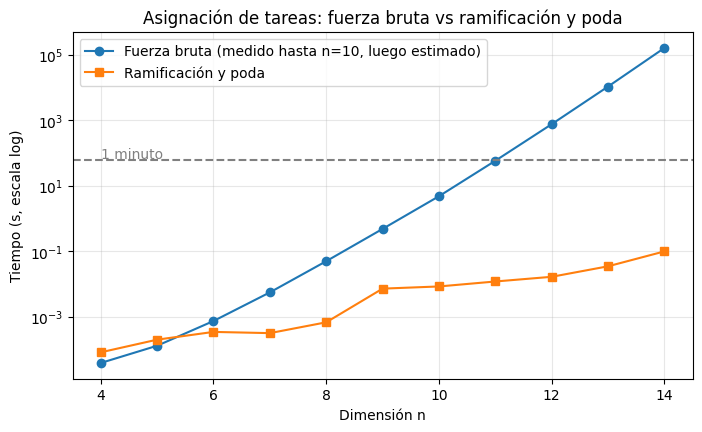

In [37]:
ns = [r[0] for r in resultados]
plt.figure(figsize=(8, 4.5))
plt.semilogy(ns, [r[1] for r in resultados], "o-", label="Fuerza bruta (medido hasta n=10, luego estimado)")
plt.semilogy(ns, [r[2] for r in resultados], "s-", label="Ramificación y poda")
plt.axhline(60, ls="--", c="gray"); plt.text(4, 70, "1 minuto", color="gray")
plt.xlabel("Dimensión n"); plt.ylabel("Tiempo (s, escala log)")
plt.title("Asignación de tareas: fuerza bruta vs ramificación y poda")
plt.legend(); plt.grid(alpha=.3); plt.show()

In [38]:
# ¿Hasta dónde llega R&P? Tamaños mayores, 3 matrices aleatorias por tamaño
print(f"{'n':>3} | {'mín':>8} | {'mediana':>8} | {'máx':>8}")
for n in (12, 16, 18, 20, 22, 24):
    tiempos = []
    for _ in range(3):
        c = matriz_aleatoria(n)
        t0 = time.perf_counter(); ramificacion_y_poda(c); tiempos.append(time.perf_counter() - t0)
    tiempos.sort()
    print(f"{n:3d} | {tiempos[0]:7.3f}s | {tiempos[1]:7.3f}s | {tiempos[-1]:7.3f}s")

  n |      mín |  mediana |      máx
 12 |   0.009s |   0.020s |   0.039s
 16 |   0.126s |   0.169s |   0.342s
 18 |   0.411s |   0.678s |   1.419s
 20 |   0.885s |  28.601s |  53.777s
 22 |   0.244s |   0.339s |   6.141s
 24 |   7.722s |  30.025s |  64.979s


**Conclusiones del análisis**

Como criterio práctico, un algoritmo se considera viable si resuelve el problema en menos de un minuto.

**1. ¿A partir de qué dimensión deja de ser una opción la fuerza bruta?**

La fuerza bruta evalúa las $n!$ asignaciones posibles, con un coste de $O(n \cdot n!)$. Cada vez que $n$ aumenta en 1, el tiempo se multiplica aproximadamente por $n+1$:

| $n$ | Asignaciones ($n!$) | Tiempo de fuerza bruta |
|---|---|---|
| 10 | $3{,}6 \cdot 10^6$ | ~3 s (medido) |
| 11 | $4{,}0 \cdot 10^7$ | ~30 s (estimado) |
| 12 | $4{,}8 \cdot 10^8$ | ~7 min (estimado) |
| 13 | $6{,}2 \cdot 10^9$ | ~1,6 h (estimado) |
| 14 | $8{,}7 \cdot 10^{10}$ | ~1 día (estimado) |

**Conclusión:** la fuerza bruta deja de ser una opción a partir de **$n = 12$**. Con $n = 11$ todavía es asumible, pero cada ciudad adicional multiplica el tiempo por más de 10.

**2. ¿Hay alguna dimensión a partir de la cual ramificación y poda también deja de ser válida?**

Sí. Ramificación y poda escala mucho mejor gracias a la cota inferior, que descarta casi todo el árbol. Con $n = 14$ solo genera unos pocos miles de nodos de los más de $10^{11}$ que tiene el árbol completo (columna *% árbol*). Aun así:

* Hasta **$n \approx 18$** resuelve cualquier matriz aleatoria en menos de un segundo.
* Con **$n = 20$–$24$** el tiempo varía muchísimo entre matrices del mismo tamaño: desde décimas de segundo hasta más de 30 s. El rendimiento depende de lo bien que pode la cota en cada caso concreto.
* En pruebas adicionales con **$n = 25$**, alguna matriz ya tardó cerca de un minuto.

**Conclusión:** con esta implementación en Python, ramificación y poda deja de ser una opción fiable hacia **$n \approx 25$–$30$**. La poda retrasa la explosión combinatoria, pero no la elimina: en el peor caso, si la cota no descarta nada, la complejidad sigue siendo factorial.

**3. Reflexión final**

Para el problema de asignación existe un algoritmo exacto polinómico, el **algoritmo húngaro** ($O(n^3)$), usado aquí como referencia mediante `scipy.optimize.linear_sum_assignment`. Resuelve matrices de $1000 \times 1000$ en una fracción de segundo. Por tanto, en este problema concreto ninguno de los dos métodos estudiados es la mejor elección para tamaños grandes.

Ramificación y poda resulta realmente útil en problemas para los que no se conoce un algoritmo polinómico, los **NP-difíciles**, como el problema del viajante (TSP) o el de la mochila. En ellos es una de las pocas técnicas que garantizan la solución óptima explorando solo una pequeña parte del espacio de búsqueda.

## 3. Descenso del gradiente

Partimos de un punto $P_0$ y avanzamos en sentido contrario al gradiente:

$$P_{k+1} = P_k - \alpha_k \,\nabla f(P_k)$$

donde $\alpha_k$ es la tasa de aprendizaje. Un $\alpha$ grande avanza rápido pero puede oscilar o divergir; uno pequeño converge despacio. Por eso se suele reducir a medida que avanzan las iteraciones.

### 3.1 Paraboloide $f(x,y) = x^2 + y^2$
El mínimo está en $(0,0)$. $\nabla f = (2x,\ 2y)$.

In [39]:
f_par = lambda X: X[0]**2 + X[1]**2
df_par = lambda X: np.array([2 * X[0], 2 * X[1]])

def descenso_gradiente(f, df, P0, TA=0.1, iteraciones=500, decaimiento=0.0, tol=1e-8):
    """Devuelve el punto final y la trayectoria. TA_k = TA / (1 + decaimiento·k)."""
    P = np.array(P0, dtype=float)
    trayectoria = [P.copy()]
    for k in range(iteraciones):
        grad = df(P)
        if np.linalg.norm(grad) < tol:          # criterio de parada: gradiente casi nulo
            break
        P = P - TA / (1 + decaimiento * k) * grad
        trayectoria.append(P.copy())
    return P, np.array(trayectoria)

def mapa_niveles(f, xr, yr, res=200, ax=None):
    X = np.linspace(*xr, res); Y = np.linspace(*yr, res)
    XX, YY = np.meshgrid(X, Y)
    Z = np.vectorize(lambda a, b: f((a, b)))(XX, YY)
    ax = ax or plt.gca()
    cs = ax.contourf(XX, YY, Z, 60, cmap="viridis")
    return cs

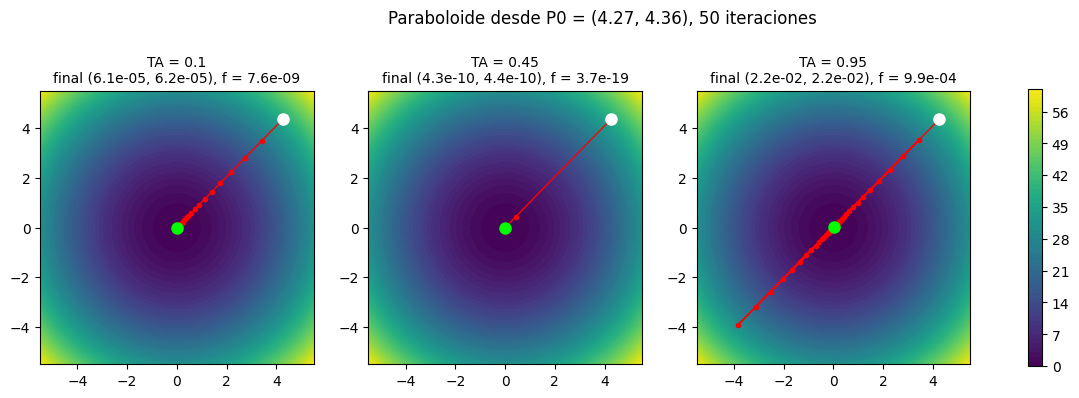

Con TA < 1 cada paso multiplica P por (1 - 2·TA): con 0.1 converge suave, con 0.45 casi en un salto
y con 0.95 oscila de un lado a otro del mínimo. Con TA > 1 divergiría.


In [40]:
P0 = [random.choice([-1, 1]) * random.uniform(3, 5), random.choice([-1, 1]) * random.uniform(3, 5)]  # lejos del mínimo

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, TA in zip(axes, (0.1, 0.45, 0.95)):
    P, tr = descenso_gradiente(f_par, df_par, P0, TA=TA, iteraciones=50)
    cs = mapa_niveles(f_par, (-5.5, 5.5), (-5.5, 5.5), ax=ax)
    ax.plot(tr[:, 0], tr[:, 1], "o-", c="red", ms=3, lw=1)
    ax.plot(*tr[0], "o", c="white", ms=8); ax.plot(*tr[-1], "o", c="lime", ms=8)
    ax.set_title(f"TA = {TA}\nfinal ({P[0]:.1e}, {P[1]:.1e}), f = {f_par(P):.1e}", fontsize=10)
    ax.set_aspect("equal")
fig.colorbar(cs, ax=axes, shrink=.8)
plt.suptitle(f"Paraboloide desde P0 = ({P0[0]:.2f}, {P0[1]:.2f}), 50 iteraciones")
plt.show()

print("Con TA < 1 cada paso multiplica P por (1 - 2·TA): con 0.1 converge suave, con 0.45 casi en un salto")
print("y con 0.95 oscila de un lado a otro del mínimo. Con TA > 1 divergiría.")

### 3.2 Actividad extra: minimizar una función con muchos mínimos locales

$$f(x,y) = \sin\left(\tfrac{1}{2}x^2 - \tfrac{1}{4}y^2 + 3\right)\cdot\cos\left(2x + 1 - e^{y}\right)$$

A diferencia del paraboloide, esta función tiene **muchos mínimos locales**, así que el descenso del gradiente puede quedarse atascado según el punto de partida. Como es el producto de un seno y un coseno, su valor mínimo posible es $-1$, que se alcanza cuando un factor vale $1$ y el otro $-1$. Ese valor sirve para saber si hemos encontrado un mínimo global.

**Gradiente analítico.** Con $u = \tfrac{1}{2}x^2 - \tfrac{1}{4}y^2 + 3$ y $v = 2x + 1 - e^y$:

$$\frac{\partial f}{\partial x} = x\cos u\cos v - 2\sin u\sin v, \qquad
\frac{\partial f}{\partial y} = -\frac{y}{2}\cos u\cos v + e^{y}\sin u\sin v$$

Antes de usarlo, se comprueba que coincide con un gradiente numérico calculado por diferencias centrales.

El gradiente analítico coincide con el numérico.


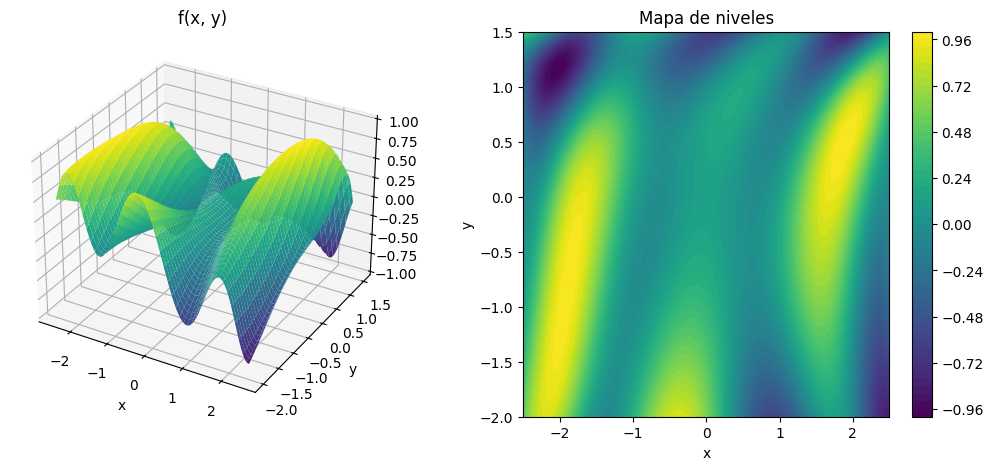

In [41]:
def f(X):
    x, y = X
    return math.sin(0.5 * x**2 - 0.25 * y**2 + 3) * math.cos(2 * x + 1 - math.exp(y))

def df(X):
    x, y = X
    u, v = 0.5 * x**2 - 0.25 * y**2 + 3, 2 * x + 1 - math.exp(y)
    return np.array([x * math.cos(u) * math.cos(v) - 2 * math.sin(u) * math.sin(v),
                     -0.5 * y * math.cos(u) * math.cos(v) + math.exp(y) * math.sin(u) * math.sin(v)])

def df_numerico(f, X, h=1e-6):
    X = np.array(X, dtype=float)
    return np.array([(f(X + h * e) - f(X - h * e)) / (2 * h) for e in np.eye(len(X))])

for _ in range(5):
    X = (random.uniform(-2, 2), random.uniform(-2, 1.5))
    assert np.allclose(df(X), df_numerico(f, X), atol=1e-6)
print("El gradiente analítico coincide con el numérico.")

fig = plt.figure(figsize=(13, 5))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
xs, ys = np.meshgrid(np.linspace(-2.5, 2.5, 150), np.linspace(-2, 1.5, 150))
zs = np.vectorize(lambda a, b: f((a, b)))(xs, ys)
ax3.plot_surface(xs, ys, zs, cmap="viridis", linewidth=0)
ax3.set_title("f(x, y)"); ax3.set_xlabel("x"); ax3.set_ylabel("y")
ax2 = fig.add_subplot(1, 2, 2)
fig.colorbar(mapa_niveles(f, (-2.5, 2.5), (-2, 1.5), ax=ax2), ax=ax2)
ax2.set_title("Mapa de niveles"); ax2.set_xlabel("x"); ax2.set_ylabel("y")
plt.show()

**Estrategia:**
1. **Tasa de aprendizaje decreciente**, $\alpha_k = \alpha_0/(1+0{,}01k)$, para avanzar rápido al principio y afinar al final.
2. **Recorte del paso**: como $e^y$ hace que el gradiente sea muy grande para $y>1$, se limita la longitud de cada paso para evitar saltos que nos saquen de la región.
3. **Región de búsqueda acotada**: $x\in[-2{,}5;\,2{,}5]$, $y\in[-2;\,1{,}5]$. Si un paso se sale, el punto se proyecta de vuelta al borde (descenso del gradiente proyectado).
4. **Multiarranque**: el descenso del gradiente solo garantiza un mínimo *local*, así que se lanza desde muchos puntos aleatorios y se queda el mejor.

In [42]:
LIMITES = np.array([[-2.5, 2.5], [-2.0, 1.5]])   # región de búsqueda: x ∈ [-2.5, 2.5], y ∈ [-2, 1.5]

def descenso_gradiente_v2(f, df, P0, TA=0.05, iteraciones=2000, decaimiento=0.01,
                          paso_max=0.25, tol=1e-8):
    P = np.array(P0, dtype=float)
    trayectoria = [P.copy()]
    for k in range(iteraciones):
        grad = df(P)
        if np.linalg.norm(grad) < tol:
            break
        paso = TA / (1 + decaimiento * k) * grad
        norma = np.linalg.norm(paso)
        if norma > paso_max:                     # recorte del paso
            paso *= paso_max / norma
        P = np.clip(P - paso, LIMITES[:, 0], LIMITES[:, 1])   # proyección a la región de búsqueda
        trayectoria.append(P.copy())
    return P, np.array(trayectoria)

N_ARRANQUES = 40
resultados_gd = []
for _ in range(N_ARRANQUES):
    P0 = (random.uniform(-2.5, 2.5), random.uniform(-2, 1.5))
    P, tr = descenso_gradiente_v2(f, df, P0)
    resultados_gd.append((f(P), P, tr))

resultados_gd.sort(key=lambda r: r[0])
mejor_f, mejor_P, _ = resultados_gd[0]
print(f"Mejor mínimo encontrado: f({mejor_P[0]:.6f}, {mejor_P[1]:.6f}) = {mejor_f:.8f}")
print(f"Gradiente en ese punto : {df(mejor_P)}")
print(f"Arranques que alcanzan f < -0.999: {sum(r[0] < -0.999 for r in resultados_gd)} de {N_ARRANQUES}")
print("Distintos mínimos locales alcanzados (valor de f):",
      sorted({round(r[0], 3) for r in resultados_gd})[:10], "...")

Mejor mínimo encontrado: f(-2.027651, 1.171827) = -1.00000000
Gradiente en ese punto : [-7.31727672e-09 -5.70406907e-09]
Arranques que alcanzan f < -0.999: 6 de 40
Distintos mínimos locales alcanzados (valor de f): [-1.0, -0.851, -0.838, -0.639, -0.597, -0.061, -0.042, -0.041, -0.037] ...


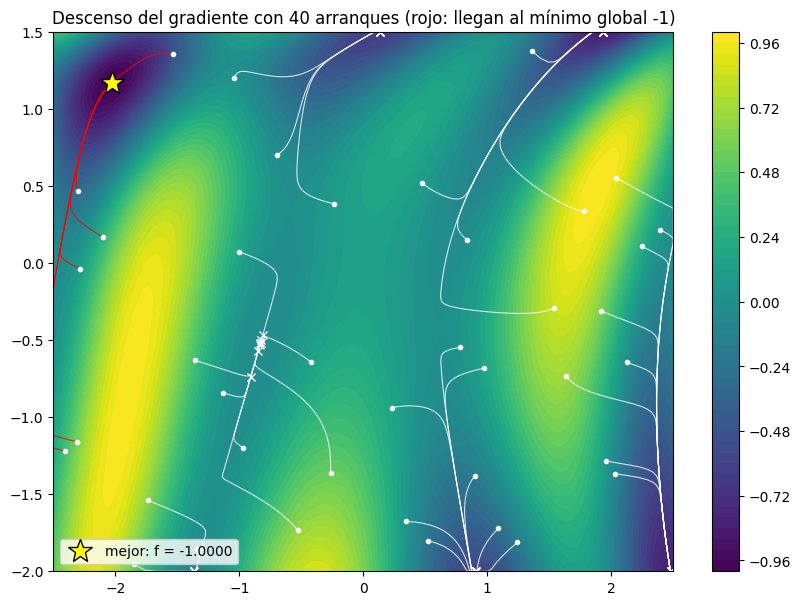

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.colorbar(mapa_niveles(f, (-2.5, 2.5), (-2, 1.5), ax=ax), ax=ax)
for valor_f, P, tr in resultados_gd:
    color = "red" if valor_f < -0.999 else "white"
    ax.plot(tr[:, 0], tr[:, 1], "-", c=color, lw=0.8, alpha=0.8)
    ax.plot(*tr[0], "o", c="white", ms=3)
    ax.plot(*P, "x", c=color, ms=6)
ax.plot(*mejor_P, "*", c="yellow", ms=18, mec="black", label=f"mejor: f = {mejor_f:.4f}")
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2, 1.5)
ax.set_title(f"Descenso del gradiente con {N_ARRANQUES} arranques (rojo: llegan al mínimo global -1)")
ax.legend(loc="lower left"); plt.show()

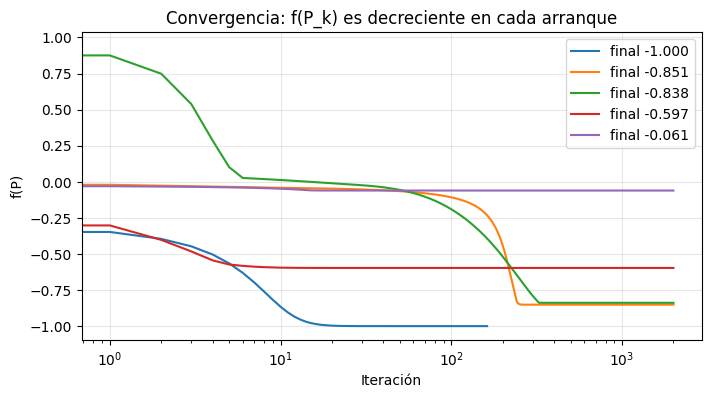

BFGS (scipy) partiendo del mejor punto: f = -1.0000000000 en (-2.027651, 1.171827)


In [44]:
# Evolución de f a lo largo de las iteraciones para algunos arranques
plt.figure(figsize=(8, 4))
for valor_f, P, tr in resultados_gd[::8]:
    plt.plot([f(p) for p in tr], label=f"final {valor_f:.3f}")
plt.xscale("log"); plt.xlabel("Iteración"); plt.ylabel("f(P)")
plt.title("Convergencia: f(P_k) es decreciente en cada arranque"); plt.legend(); plt.grid(alpha=.3); plt.show()

# Contraste con un optimizador de referencia
from scipy.optimize import minimize
ref = minimize(f, mejor_P, jac=df, method="BFGS")
print(f"BFGS (scipy) partiendo del mejor punto: f = {ref.fun:.10f} en ({ref.x[0]:.6f}, {ref.x[1]:.6f})")

**Conclusiones del descenso del gradiente**

**1. Paraboloide $f(x,y) = x^2 + y^2$ (función convexa).**
Cada paso del algoritmo es $P_{k+1} = P_k - \alpha \cdot 2P_k = (1 - 2\alpha)\,P_k$, así que el comportamiento depende solo de la tasa de aprendizaje $\alpha$:

| Tasa $\alpha$ | Comportamiento |
|---|---|
| $0 < \alpha < 0{,}5$ | Converge de forma suave y monótona al mínimo |
| $\alpha = 0{,}5$ | Llega al mínimo en un solo paso |
| $0{,}5 < \alpha < 1$ | Converge, pero oscilando de un lado a otro del mínimo |
| $\alpha \geq 1$ | No converge: oscila sin fin ($\alpha = 1$) o diverge ($\alpha > 1$) |

Como la función es convexa, solo tiene un mínimo y el algoritmo lo encuentra desde cualquier punto de partida, siempre que $\alpha$ sea adecuada. La tasa solo influye en la velocidad y en si hay oscilaciones.

**2. Función propuesta (con muchos mínimos locales).**
El descenso del gradiente solo garantiza llegar a un mínimo **local**: cada arranque acaba en el "valle" más cercano a su punto de partida. En la ejecución, de 40 arranques aleatorios solo unos pocos alcanzan $f < -0{,}999$; el resto se queda en mínimos locales con valores como $-0{,}85$ o $-0{,}64$.

El **multiarranque** soluciona este problema: el mejor punto encontrado tiene $f = -1$, con gradiente prácticamente nulo. Como $-1$ es el valor más bajo que puede tomar la función, ese punto es un **mínimo global**. Además, el optimizador BFGS de `scipy` confirma el resultado. La función tiene varios mínimos globales, y cada arranque exitoso puede encontrar uno distinto.

**3. Ajustes que hacen el método robusto.**
* **Tasa de aprendizaje decreciente:** pasos grandes al principio para avanzar rápido y pequeños al final para afinar sin oscilar.
* **Recorte del paso:** en la zona $y > 1$ el término $e^y$ hace que el gradiente sea muy grande. Sin recorte, un solo paso podría sacar el punto muy lejos de la región de interés.
* **Región acotada:** si un paso se sale de la región de búsqueda, el punto se devuelve al borde.

**Conclusión general:** en funciones convexas basta con elegir bien la tasa de aprendizaje. En funciones con muchos mínimos locales, el descenso del gradiente necesita combinarse con estrategias de diversificación como el multiarranque, igual que las metaheurísticas de búsqueda local. Es la misma situación que se da al entrenar redes neuronales, donde la función de pérdida no es convexa.